# Job Market Trends - Exploratory Data Analysis

This notebook analyzes the cleaned and enriched job market dataset to identify key trends in salaries, remote work, and **skills demand**.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Load Cleaned Data

In [2]:
df = pd.read_csv('../linkedin_jobs_dashboard_ready.csv')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120447 entries, 0 to 120446
Data columns (total 14 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   job_id              120447 non-null  int64  
 1   final_company_name  120447 non-null  object 
 2   title               120447 non-null  object 
 3   location            120447 non-null  object 
 4   industry_name       1831 non-null    object 
 5   top_skills          118739 non-null  object 
 6   company_size        113985 non-null  float64
 7   employee_count      118772 non-null  float64
 8   is_remote           120447 non-null  object 
 9   experience_group    120447 non-null  object 
 10  normalized_salary   32671 non-null   float64
 11  demand_score        120447 non-null  float64
 12  year                120447 non-null  int64  
 13  month               120447 non-null  int64  
dtypes: float64(4), int64(3), object(7)
memory usage: 12.9+ MB


,job_id,final_company_name,title,location,industry_name,top_skills,company_size,employee_count,is_remote,experience_group,normalized_salary,demand_score,year,month
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,"Princeton, NJ",NaN,"Marketing, Sales",2.0,402.0,Onsite,Not Specified,38480.0,24.0,2024,4
1,1829192,Unknown,Mental Health Therapist/Counselor,"Fort Collins, CO",Unknown,Health Care Provider,NaN,NaN,Onsite,Not Specified,83200.0,1.0,2024,4
2,10998357,The National Exemplar,Assitant Restaurant Manager,"Cincinnati, OH",NaN,"Management, Manufacturing",1.0,15.0,Onsite,Not Specified,55000.0,8.0,2024,4
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,"New Hyde Park, NY",NaN,Other,2.0,222.0,Onsite,Not Specified,157500.0,16.0,2024,4
4,35982263,Unknown,Service Technician,"Burlington, IA",Unknown,Information Technology,NaN,NaN,Onsite,Not Specified,70000.0,3.0,2024,4


## 1.5 Null Audit

In [3]:
null_pct = (df.isnull().sum() / len(df) * 100).round(2)
print(null_pct[null_pct > 0].sort_values(ascending=False))

industry_name        98.48
normalized_salary    72.88
company_size          5.37
top_skills            1.42
employee_count        1.39
dtype: float64


## 2. Salary Analysis

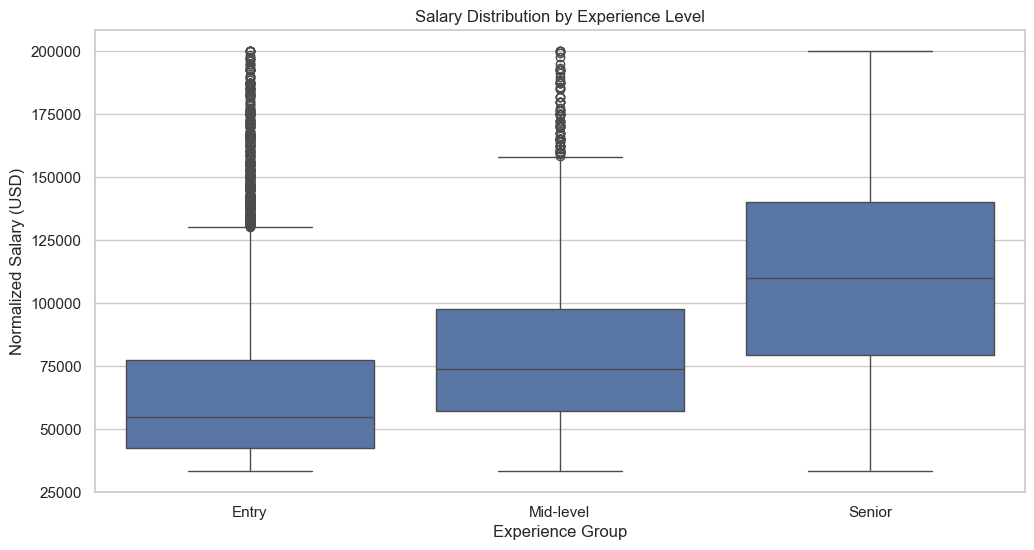

In [4]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[df['normalized_salary'].notna()], x='experience_group', y='normalized_salary', order=['Entry', 'Mid-level', 'Senior'])
plt.title('Salary Distribution by Experience Level')
plt.ylabel('Normalized Salary (USD)')
plt.xlabel('Experience Group')
plt.show()

## 2.5 Remote vs Onsite Salary Gap

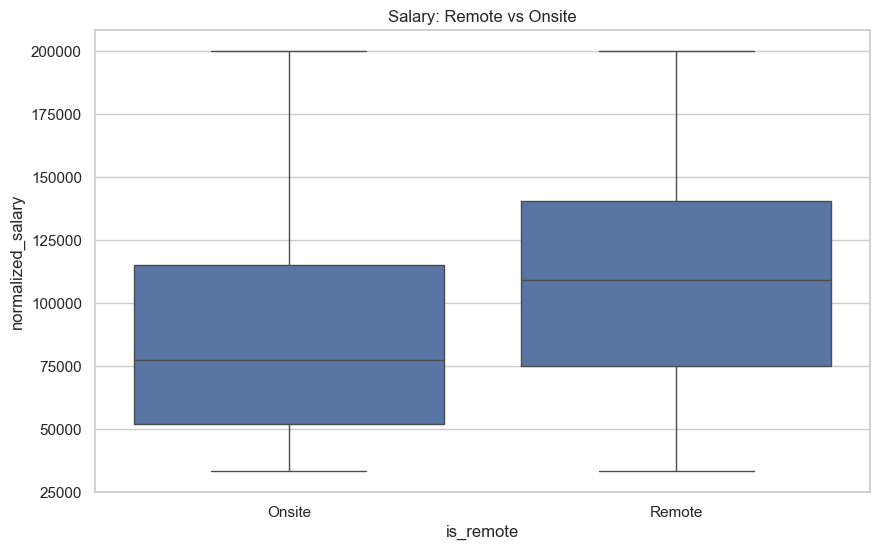

In [5]:
sns.boxplot(data=df[df['normalized_salary'].notna()], 
            x='is_remote', y='normalized_salary')
plt.title('Salary: Remote vs Onsite')
plt.show()

## 3. Remote Work Trends

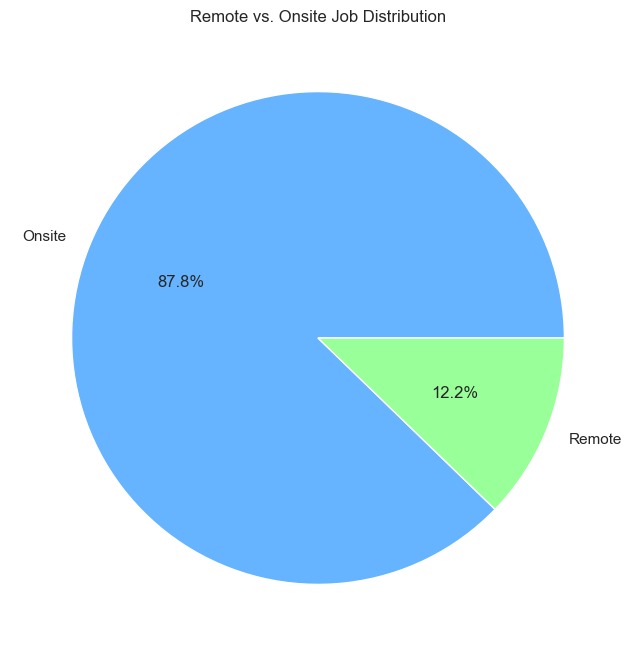

In [6]:
remote_counts = df['is_remote'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(remote_counts, labels=remote_counts.index, autopct='%1.1f%%', colors=['#66b3ff','#99ff99'])
plt.title('Remote vs. Onsite Job Distribution')
plt.show()

## 3.5 Monthly Job Posting Trend

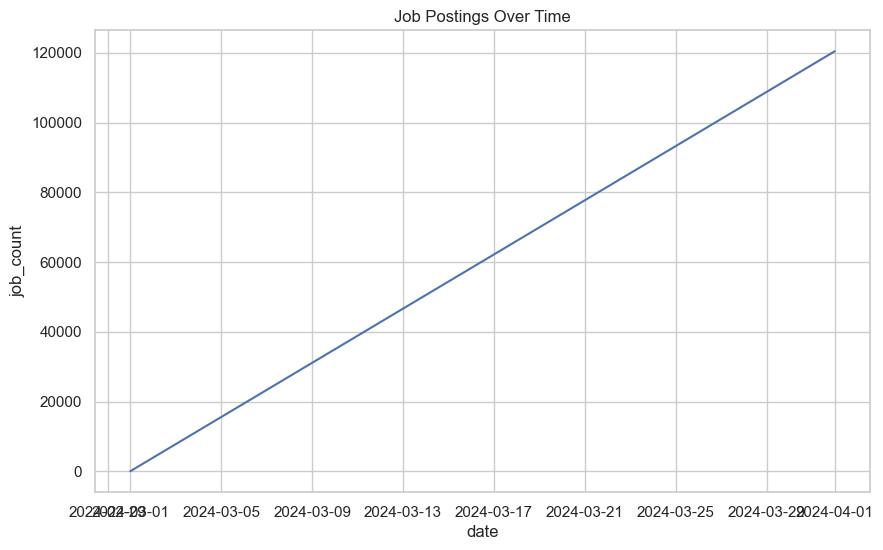

In [7]:
monthly = df.groupby(['year', 'month']).size().reset_index(name='job_count')
monthly['date'] = pd.to_datetime(monthly[['year', 'month']].assign(day=1))
sns.lineplot(data=monthly, x='date', y='job_count')
plt.title('Job Postings Over Time')
plt.show()

## 4. Top Skills in High Demand

/var/folders/34/dvd868kj0m19y8y9vm0bvgk00000gn/T/ipykernel_5708/1791117452.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=skills_series.values, y=skills_series.index, palette='crest')


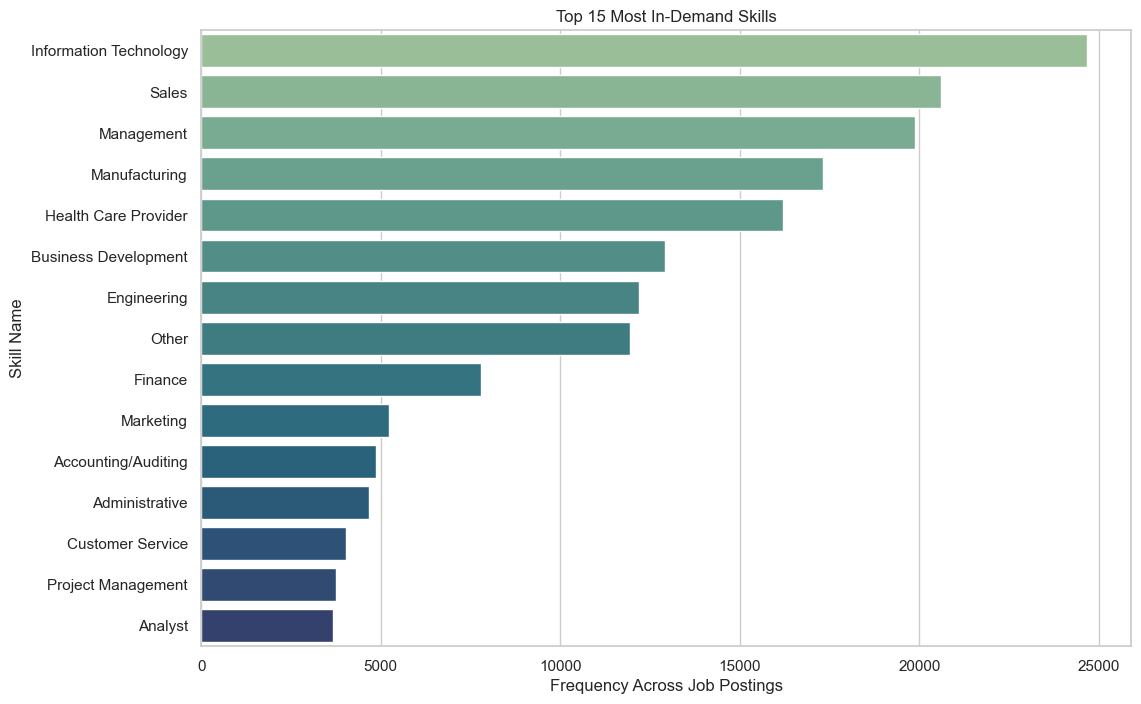

In [8]:
# Flatten the top_skills column (comma-separated strings)
skills_series = df['top_skills'].str.split(', ').explode().value_counts().head(15)

plt.figure(figsize=(12, 8))
sns.barplot(x=skills_series.values, y=skills_series.index, palette='crest')
plt.title('Top 15 Most In-Demand Skills')
plt.xlabel('Frequency Across Job Postings')
plt.ylabel('Skill Name')
plt.show()

## 5. Top Industries by Job Volume

/var/folders/34/dvd868kj0m19y8y9vm0bvgk00000gn/T/ipykernel_5708/1963964031.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_industries.values, y=top_industries.index, palette='viridis')


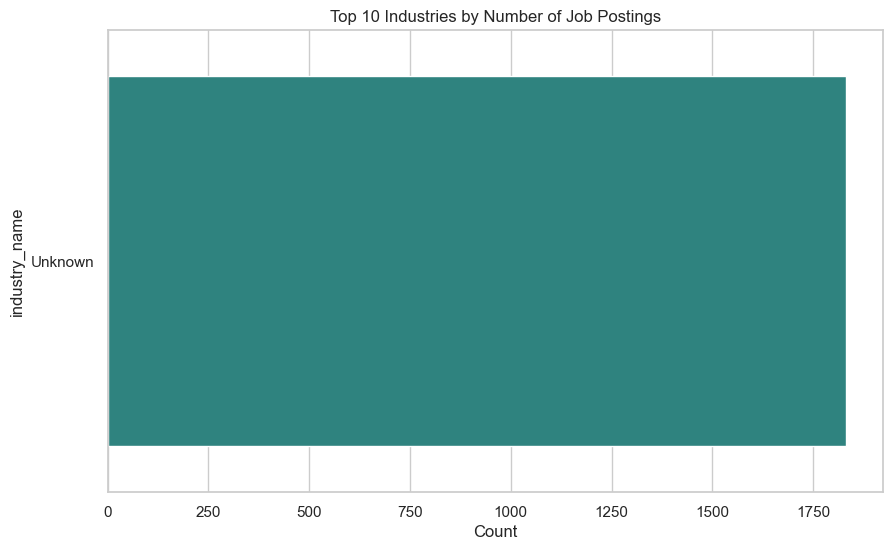

In [10]:
top_industries = df['industry_name'].str.split(', ').explode().value_counts().head(10)
sns.barplot(x=top_industries.values, y=top_industries.index, palette='viridis')
plt.title('Top 10 Industries by Number of Job Postings')
plt.xlabel('Count')
plt.show()

## 5.5 Median Salary by Industry

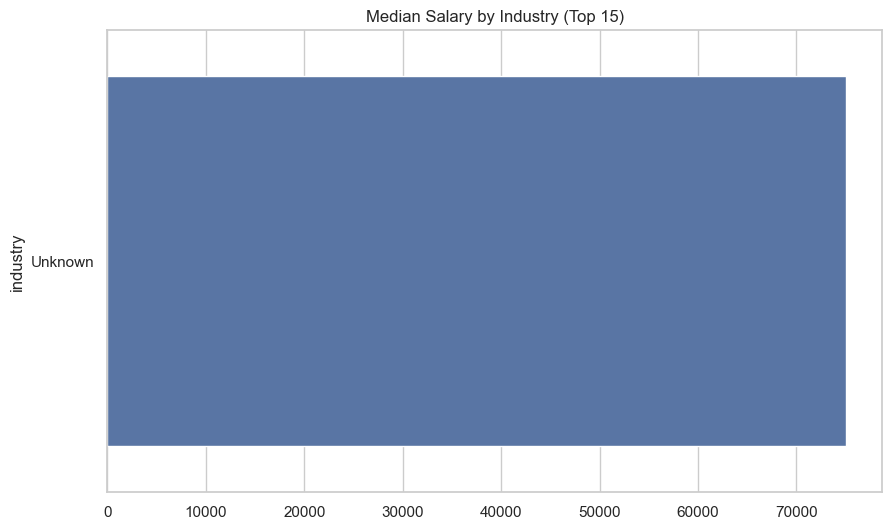

In [11]:
df_ind = df.assign(industry=df['industry_name'].str.split(', ')).explode('industry')
industry_salary = df_ind.groupby('industry')['normalized_salary'].median().sort_values(ascending=False).head(15)
sns.barplot(x=industry_salary.values, y=industry_salary.index)
plt.title('Median Salary by Industry (Top 15)')
plt.show()

## 6. Demand Score vs. Company Size

/var/folders/34/dvd868kj0m19y8y9vm0bvgk00000gn/T/ipykernel_5708/2804722814.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_demand.index, y=avg_demand.values, palette='magma')


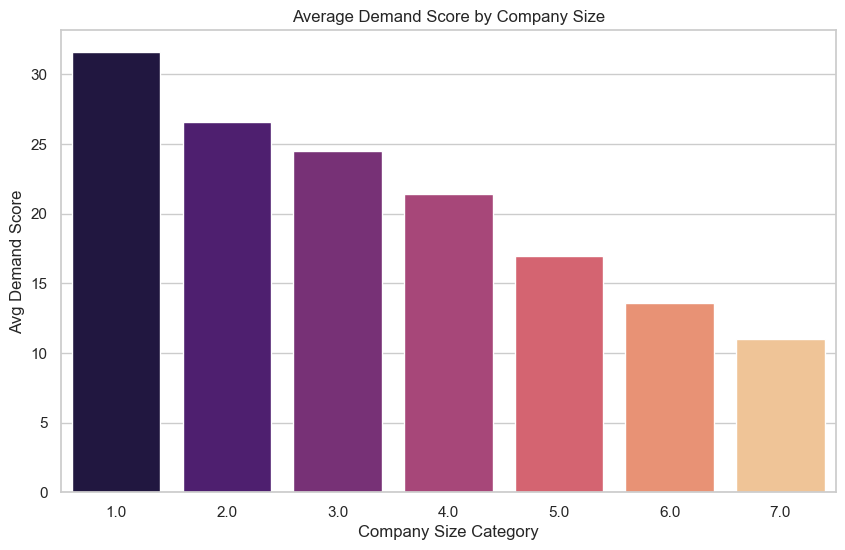

In [12]:
avg_demand = df.groupby('company_size')['demand_score'].mean().sort_values(ascending=False)
sns.barplot(x=avg_demand.index, y=avg_demand.values, palette='magma')
plt.title('Average Demand Score by Company Size')
plt.ylabel('Avg Demand Score')
plt.xlabel('Company Size Category')
plt.show()

## 7. Correlation Heatmap


Skipping missing columns: ['views', 'applies']


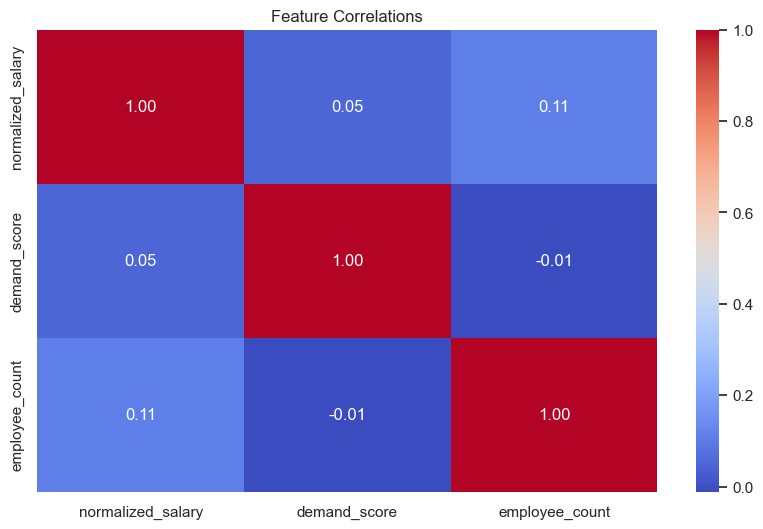

In [14]:
corr_cols = ['normalized_salary', 'demand_score', 'employee_count', 'views', 'applies']
available_corr_cols = [c for c in corr_cols if c in df.columns]

if len(available_corr_cols) < 2:
	raise ValueError(f"Need at least 2 valid columns for correlation. Found: {available_corr_cols}")

missing_corr_cols = [c for c in corr_cols if c not in df.columns]
if missing_corr_cols:
	print(f"Skipping missing columns: {missing_corr_cols}")

sns.heatmap(df[available_corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlations')
plt.show()